In [1]:
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    PrecisionRecallDisplay,
    classification_report
)

In [2]:
model = joblib.load("X:/AI-SPAM-PHISHING-DETECTOR/models/spam_classifier.pkl")

X_test = joblib.load("X:/AI-SPAM-PHISHING-DETECTOR/models/X_test.pkl")
y_test = joblib.load("X:/AI-SPAM-PHISHING-DETECTOR/models/y_test.pkl")

In [3]:
y_pred = model.predict(X_test)

In [4]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       886
           1       0.98      0.84      0.91       285

    accuracy                           0.96      1171
   macro avg       0.97      0.92      0.94      1171
weighted avg       0.96      0.96      0.96      1171



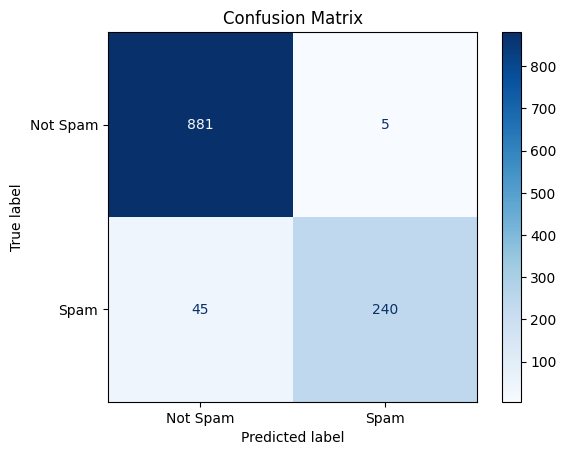

In [5]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Spam", "Spam"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

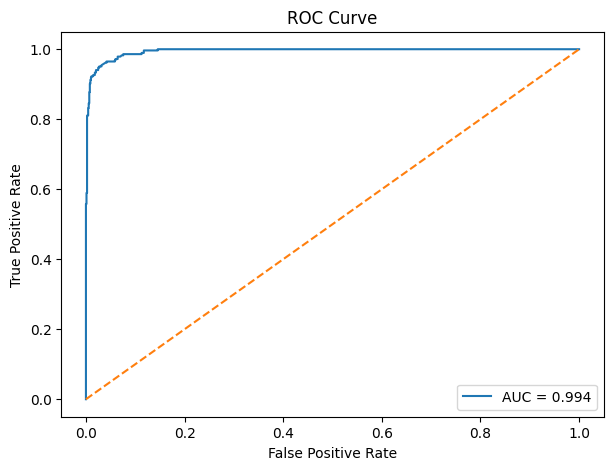

In [6]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

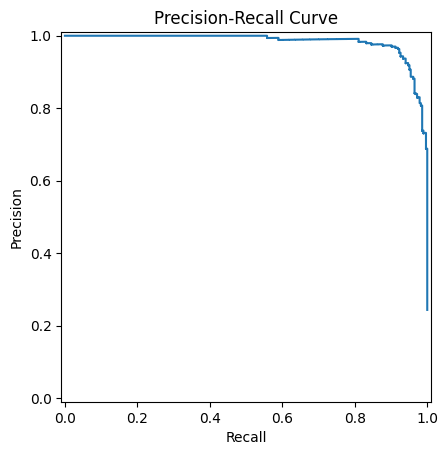

In [7]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_prob
)

display = PrecisionRecallDisplay(
    precision=precision,
    recall=recall
)

display.plot()

plt.title("Precision-Recall Curve")

plt.show()

## Model Evaluation Summary

- Best Model: Multinomial Naive Bayes
- TF-IDF features were used.
- The model achieved high accuracy in detecting spam emails.
- ROC curve indicates strong classification performance.
- Confusion matrix shows most emails are correctly classified.
- This model was selected for deployment in the Streamlit application.